# **Territorial behavior in football**

Animals that fight over territory don't fight the same way everywhere. A bird defending its own nest will often escalate a contest that it would walk away from on neutral ground; the same individual can behave like two different animals depending on whether it currently "owns" the contested space. Evolutionary game theory has a name for this: **territorial behavior conditioned on ownership**, and a well-studied model for why it evolves — the **Hawk-Dove game** and its extension, the **ownership game**.

This notebook asks a simple question: do football teams show the same pattern? A team's home stadium is its territory in a very literal sense — and if territorial conditioning is a general enough phenomenon, it should be detectable in how aggressively a team presses for the ball, using nothing but publicly available match data.

## The Hawk-Dove game, briefly

Two animals contest a resource worth $V$ to whoever gets it. Each can play **Hawk** (escalate, risk a costly fight) or **Dove** (display, back off if challenged). If a fight's cost $C$ exceeds the resource's value $V$, neither pure strategy is stable: an all-Hawk population pays crippling injury costs, but an all-Dove population is exploitable by a single Hawk. The population settles into a mix of the two instead.

There's a cleverer solution, though, whenever the two contestants can tell themselves apart by some arbitrary asymmetry — such as which one already occupies the territory. The **Bourgeois** strategy conditions behavior on that asymmetry: play Hawk as the owner, Dove as the intruder. Bourgeois lets contests resolve without a fight most of the time (the intruder yields to the owner) while still being able to win territory outright when it is the owner — and it turns out to be evolutionarily stable even though ownership itself confers no fighting advantage at all. **Antibourgeois** (Dove as owner, Hawk as intruder) is the mirror image, and is stable under the same conditions for the same reason — which strategy a population actually settles into is historically arbitrary, not something the payoffs alone determine.

Mapped onto football, home status is the ownership asymmetry: a team playing at home is the "owner," a team playing away is the "intruder." That gives four candidate strategies for any team to display across a season:

| Strategy | Home behavior | Away behavior |
|---|---|---|
| **Hawk** | aggressive | aggressive |
| **Dove** | passive | passive |
| **Bourgeois** | aggressive | passive |
| **Antibourgeois** | passive | aggressive |

Testing whether this pattern shows up in football requires one thing this project builds from scratch: a way to measure "aggressive" from match data.

## Data

StatsBomb's open data release for the 2015/16 season covers the Premier League, La Liga, Serie A, and Ligue 1 with full round-robin event data for every match — every pass, tackle, interception, pressure, and foul, with pitch coordinates for each. This analysis uses those four leagues.

In [1]:
# Colab-specific setup
import sys

if "google.colab" in sys.modules:
    %pip install -q statsbombpy

In [2]:
import os
from statsbombpy import sb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning)

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

pd.set_option("display.max_columns", None)

TEAM_COLORS = {'AFC Bournemouth': '#DA291C', 'Arsenal': '#EF0107', 'Aston Villa': '#670E36', 'Chelsea': '#034694', 'Crystal Palace': '#1B458F', 'Everton': '#003399', 'Leicester City': '#003090', 'Liverpool': '#C8102E', 'Manchester City': '#6CABDD', 'Manchester United': '#DA291C', 'Newcastle United': '#241F20', 'Norwich City': '#FFF200', 'Southampton': '#D71920', 'Stoke City': '#E03A3E', 'Sunderland': '#EB172B', 'Swansea City': '#4C4C4C', 'Tottenham Hotspur': '#132257', 'Watford': '#FBEE23', 'West Bromwich Albion': '#122F67', 'West Ham United': '#7A263A', 'Athletic Club': '#EE2523', 'Atlético Madrid': '#CB3524', 'Barcelona': '#A50044', 'Celta Vigo': '#8AC3EE', 'Eibar': '#004B85', 'Espanyol': '#0A4C93', 'Getafe': '#005999', 'Granada': '#C60C30', 'Las Palmas': '#FFDD00', 'Levante UD': '#A6093D', 'Málaga': '#1F65AB', 'RC Deportivo La Coruña': '#0066B3', 'Rayo Vallecano': '#C10000', 'Real Betis': '#0BB363', 'Real Madrid': '#FEFEFE', 'Real Sociedad': '#0066B2', 'Sevilla': '#D80027', 'Sporting Gijón': '#EE2523', 'Valencia': '#F58426', 'Villarreal': '#FFE500', 'AS Monaco': '#E51937', 'Angers': '#000000', 'Bastia': '#1E4B8F', 'Bordeaux': '#001E62', 'Gazélec Ajaccio': '#E30613', 'Guingamp': '#E2001A', 'Lille': '#C8102E', 'Lorient': '#E4592E', 'Lyon': '#12296B', 'Montpellier': '#F47B20', 'Nantes': '#FFD200', 'OGC Nice': '#E2001A', 'Olympique de Marseille': '#2FAEE0', 'Paris Saint-Germain': '#004170', 'Rennes': '#E2001A', 'Saint-Étienne': '#52B04A', 'Stade Malherbe Caen': '#003C7D', 'Stade de Reims': '#DA020E', 'Toulouse': '#6C1D45', 'Troyes': '#0072BC', 'AC Milan': '#FB090B', 'AS Roma': '#8E1F2F', 'Atalanta': '#0B2265', 'Bologna': '#A6192E', 'Carpi': '#000000', 'Chievo': '#FFD400', 'Empoli': '#005CA9', 'Fiorentina': '#482E92', 'Frosinone': '#FFE200', 'Genoa': '#C8102E', 'Hellas Verona': '#FCD116', 'Inter Milan': '#0068A8', 'Juventus': '#000000', 'Lazio': '#87CEFA', 'Napoli': '#12A0D7', 'Palermo': '#F03A6E', 'Sampdoria': '#0F4C81', 'Sassuolo': '#00A64F', 'Torino': '#78184A', 'Udinese': '#000000'}

## Measuring aggression: forward press rate

"Aggressive" here is used in the Hawk-Dove sense — willingness to contest a resource — not the colloquial sense of physicality or fouls. Concretely, the resource being contested at any moment is territory: does a team choose to fight for the ball while the opponent still holds it in the opponent's own half, or does it wait?

**Forward press rate** is defined as: the number of defensive-action *attempts* — pressures, tackles, interceptions, and fouls committed — a team makes while the ball is in the opponent's own half, per opponent possession. Two design choices make this a clean, single, directly interpretable number rather than a composite of several noisy signals:

- **Attempts, not successes.** Whether a tackle succeeds reflects the player's skill; whether a team attempts it reflects strategy. Counting only successful recoveries would measure team quality as much as team style — exactly the confound this analysis needs to avoid.
- **Zone-restricted to the opponent's half.** A team that only engages once the ball reaches its own third scores near zero here, regardless of how effective its defending is once the ball arrives deep. This ties the score to *territorial* commitment specifically, rather than generic defensive workrate.

In [3]:
BIG4_2015_16 = {
    "La Liga": "data/aggression_raw_la_liga.csv",
    "Ligue 1": "data/aggression_raw_ligue_1.csv",
    "Premier League": "data/aggression_raw_premier_league.csv",
    "Serie A": "data/aggression_raw_serie_a.csv",
}

europe_df = pd.concat(
    [pd.read_csv(path).assign(league=league) for league, path in BIG4_2015_16.items()],
    ignore_index=True,
)

europe_df.head()

,match_id,team,opponent,venue,raw_aggression_index,league
0,3825739,Real Madrid,Sporting Gijón,Home,0.717172,La Liga
1,3825739,Sporting Gijón,Real Madrid,Away,0.649485,La Liga
2,3825848,Levante UD,Eibar,Home,0.804348,La Liga
3,3825848,Eibar,Levante UD,Away,0.730435,La Liga
4,3825895,Las Palmas,Sevilla,Home,0.680851,La Liga


## The European ranking

Averaging forward press rate across a full season gives each team a single number. Pooling all four leagues into one ranking is a useful first look, with one caveat: it isn't adjusted for cross-league differences in style or officiating, so a team's rank partly reflects which league it plays in, not only its own pressing intensity.

In [4]:
overall_ranking = europe_df.groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)
home_ranking = europe_df[europe_df["venue"] == "Home"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)
away_ranking = europe_df[europe_df["venue"] == "Away"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)

def plot_ranked_bar(series, title, xlabel, highlight=None, highlight_color="#A50044", base_color="#B0B0B0"):
    colors = [highlight_color if team == highlight else base_color for team in series.index]
    plt.figure(figsize=(8, max(4, 0.3 * len(series))))
    plt.barh(series.index, series.values, color=colors)
    plt.gca().invert_yaxis()
    plt.xlabel(xlabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def ranking_table(series, value_name="Aggression score"):
    table = series.rename(value_name).reset_index().rename(columns={"team": "Team"})
    table.index = range(1, len(table) + 1)
    table.index.name = "Rank"
    return table


with pd.option_context("display.max_rows", None):
    display(ranking_table(overall_ranking))

,Team,Aggression score
Rank,,
1,Lyon,1.025462
2,Lazio,1.009193
3,Napoli,1.007349
4,Fiorentina,0.984685
5,Eibar,0.970635
6,AFC Bournemouth,0.960475
7,AS Monaco,0.955039
8,Paris Saint-Germain,0.954725
9,Inter Milan,0.952616


A useful check before trusting a new style metric: does it track *quality* or does it track *style*? A metric that just re-derives "how good is this team" would be measuring nothing new. This ranking passes that check on its face — clubs like Eibar and Bournemouth, both modest mid-table sides in 2015/16 rather than elite ones, sit near the very top, well clear of several historically stronger clubs.

## A closer look at Barcelona's standing in the aggressiveness ranking

Barcelona's 2015/16 side, built around Messi-Suárez-Neymar and playing under a coach known for an intense collective press, is about as strong a prior as exists for a team that should score very high on any pressing metric. That makes it a useful validation case: does the ranking place Barcelona where reputation would predict?

In [5]:
la_liga_ranking = europe_df[europe_df["league"] == "La Liga"].groupby("team")["raw_aggression_index"].mean().sort_values(ascending=False)

print("European rank:", overall_ranking.index.get_loc("Barcelona") + 1, "of", len(overall_ranking))
print("La Liga rank:", la_liga_ranking.index.get_loc("Barcelona") + 1, "of", len(la_liga_ranking))
print()
print(la_liga_ranking.head(5))

European rank: 22 of 80
La Liga rank: 4 of 20

team
Eibar              0.970635
Atlético Madrid    0.952026
Athletic Club      0.951531
Barcelona          0.912943
Real Sociedad      0.848104
Name: raw_aggression_index, dtype: float64


Barcelona lands 22nd of 80 in Europe, and only 4th within La Liga itself — behind Eibar, Atlético Madrid, and Athletic Club. That's a real gap from what reputation would predict, and worth explaining rather than dismissing.

### Why the score reads lower than expected

Two genuine effects, both checked directly against the underlying event data rather than assumed.

**First, the score only measures defensive territorial behavior — not a team's capacity to occupy the opponent's territory through possession itself.** Barcelona's approach to controlling a match leans heavily on retaining the ball through technical, patient buildup play rather than winning it back repeatedly. A team that rarely needs to press, because it rarely loses the ball in the first place, will always score modestly on a metric that only counts defensive *attempts* — even if its overall territorial control of the match is exceptional. This is a real limitation of measuring only one half of territorial behavior (winning the ball back) while ignoring the other (never giving it up).

**Second, forward press rate is a ratio, and Barcelona's opponents give it an unusually small denominator.** The score divides defensive attempts by the number of times the opponent had the ball. Because Barcelona's own possessions tend to be longer, its opponents simply have fewer separate spells in possession to press against than the league average — and a ratio with a smaller denominator is intrinsically noisier from match to match, inflating match-to-match variance without indicating anything about strategy.

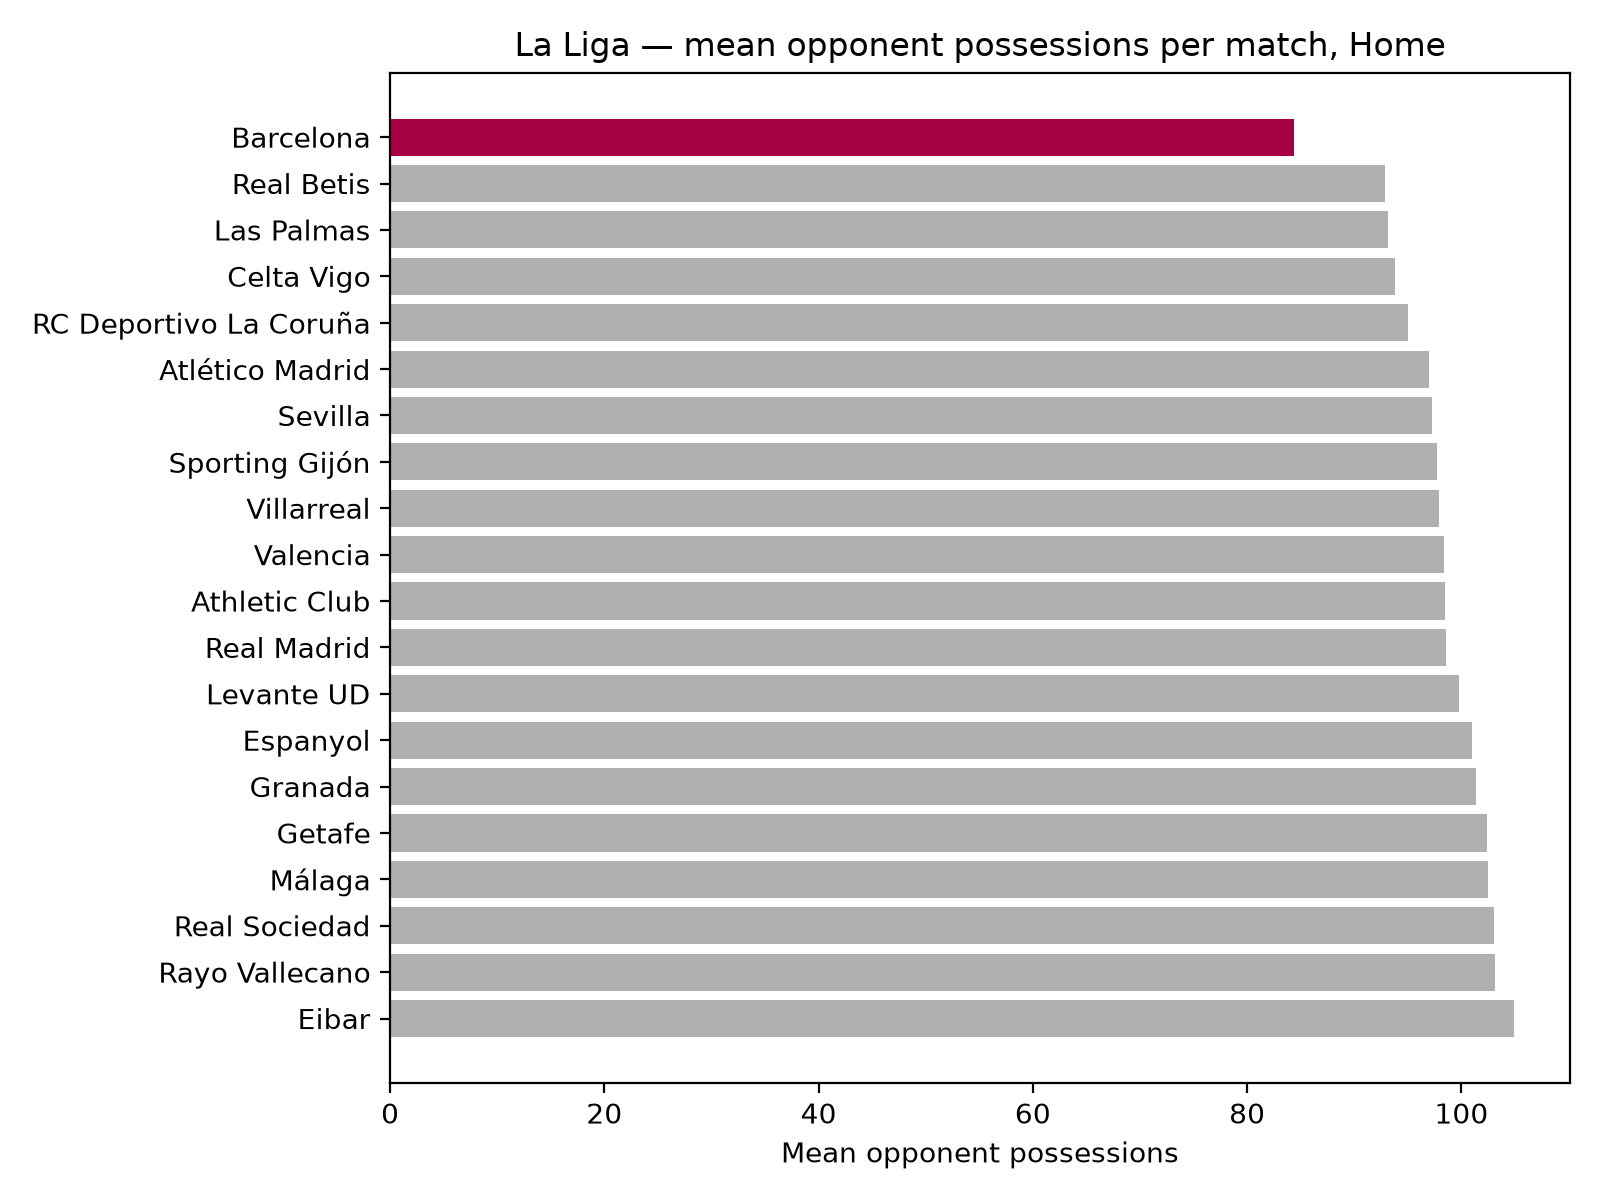

In [6]:
la_liga_diagnostics_df = pd.read_csv("data/la_liga_diagnostics.csv")

diagnostics_summary = la_liga_diagnostics_df.groupby(["team", "venue"]).agg(
    mean_opponent_possessions=("opponent_possessions", "mean"),
    std_rate=("rate", "std"),
).reset_index()

home_summary = diagnostics_summary[diagnostics_summary["venue"] == "Home"].set_index("team").drop(columns="venue")

plot_ranked_bar(
    home_summary["mean_opponent_possessions"].sort_values(),
    "La Liga — mean opponent possessions per match, Home",
    "Mean opponent possessions",
    highlight="Barcelona",
)

Barcelona's opponents average the fewest possessions per match in the league by a clear margin — confirming the small-denominator effect directly, rather than as a guess.

### Ruling out a third explanation: pressing efficiency

A natural remaining hypothesis: perhaps Barcelona simply needs *fewer* attempts to win the ball back than less technically accomplished sides — the same territorial commitment, but executed more efficiently, so it registers fewer raw attempts for the same outcome. This is directly testable using each defensive action's recorded outcome (won or lost) in the event data, compared here against Eibar and Bournemouth — two clubs that ranked above Barcelona despite far more modest reputations.

In [7]:
efficiency_df = pd.read_csv("data/pressing_efficiency_check.csv")
pressure_effectiveness_df = pd.read_csv("data/pressure_effectiveness_check.csv")

combined_efficiency_df = efficiency_df.merge(pressure_effectiveness_df, on="team")
combined_efficiency_df["combined_attempts"] = (
    combined_efficiency_df["overall_attempts"] + combined_efficiency_df["pressures_with_linked_pass"]
)
combined_efficiency_df["combined_successes"] = (
    combined_efficiency_df["overall_successes"] + combined_efficiency_df["passes_failed"]
)
combined_efficiency_df["success_rate"] = (
    combined_efficiency_df["combined_successes"] / combined_efficiency_df["combined_attempts"]
)

combined_efficiency_df[["team", "success_rate"]].sort_values("success_rate", ascending=False)

,team,success_rate
1,Eibar,0.384838
0,Barcelona,0.365462
2,AFC Bournemouth,0.357748


The hypothesis doesn't hold up: Eibar (38.5% of defensive attempts succeed) and Bournemouth (35.8%) are not less efficient than Barcelona (36.5%) — if anything Eibar is somewhat more efficient, while also attempting far more. Barcelona's lower rank isn't explained by superior recovery efficiency; the two effects established above — defense-only measurement and small-denominator variance — are the real story.

## Home versus away: the ownership map

The Hawk-Dove-Bourgeois-Antibourgeois framework gives each team a natural home for a two-axis plot: home-average forward press rate on one axis, away-average on the other. The four corners correspond to the four strategies directly — aggressive everywhere (Hawk), passive everywhere (Dove), aggressive only at home (Bourgeois), or aggressive only away (Antibourgeois). Each team's dot is shaded with a small ellipse showing the statistical uncertainty around its position (±1 standard error of the mean, given each team's home and away averages are each built from only ~19 matches).

The vertical and horizontal dashed gray lines represent the median of the distribution in each dimension (home and away aggression scores, respectively). The dashed green diagonal line is where `home_aggression=away_aggression`.

In [8]:
import plotly.graph_objects as go


def plot_home_away_scatter(csv_path, league_name):
    df = pd.read_csv(csv_path)

    home_stats = df[df["venue"] == "Home"].groupby("team")["raw_aggression_index"].agg(["mean", "sem"])
    away_stats = df[df["venue"] == "Away"].groupby("team")["raw_aggression_index"].agg(["mean", "sem"])

    stats = home_stats.join(away_stats, lsuffix="_home", rsuffix="_away").reset_index()

    fig = go.Figure()

    for _, row in stats.iterrows():
        color = TEAM_COLORS.get(row["team"], "#888888")
        fig.add_shape(
            type="circle",
            xref="x", yref="y",
            x0=row["mean_home"] - row["sem_home"], x1=row["mean_home"] + row["sem_home"],
            y0=row["mean_away"] - row["sem_away"], y1=row["mean_away"] + row["sem_away"],
            fillcolor=color, opacity=0.15, line_width=0, layer="below",
        )

    fig.add_trace(go.Scatter(
        x=stats["mean_home"], y=stats["mean_away"],
        mode="markers",
        marker=dict(size=12, color=stats["team"].map(lambda t: TEAM_COLORS.get(t, "#888888")), line=dict(color="black", width=1)),
        text=stats["team"],
        hovertemplate="<b>%{text}</b><br>Home: %{x:.2f}<br>Away: %{y:.2f}<extra></extra>",
    ))

    median_home = stats["mean_home"].median()
    median_away = stats["mean_away"].median()
    fig.add_vline(x=median_home, line_dash="dash", line_color="grey")
    fig.add_hline(y=median_away, line_dash="dash", line_color="grey")

    combined_min = min(stats["mean_home"].min(), stats["mean_away"].min())
    combined_max = max(stats["mean_home"].max(), stats["mean_away"].max())
    pad = 0.08 * (combined_max - combined_min)
    axis_lo, axis_hi = combined_min - pad, combined_max + pad

    fig.update_xaxes(range=[axis_lo, axis_hi])
    fig.update_yaxes(range=[axis_lo, axis_hi])

    fig.add_shape(
        type="line", xref="x", yref="y",
        x0=axis_lo, y0=axis_lo, x1=axis_hi, y1=axis_hi,
        line=dict(color="#2ca02c", width=1.5, dash="dot"),
        layer="below",
    )

    diag_label_pos = axis_lo + 0.22 * (axis_hi - axis_lo)
    perp_offset = 0.012 * (axis_hi - axis_lo)  # nudge perpendicular to the diagonal, in data units
    fig.add_annotation(
        x=diag_label_pos - perp_offset, y=diag_label_pos + perp_offset,
        xref="x", yref="y",
        text="home = away", showarrow=False, textangle=-45,
        font=dict(size=12, color="#2ca02c"),
        xanchor="center", yanchor="middle",
    )

    quadrant_arrows = [
        (1, 1, "More Hawkish"),
        (-1, -1, "More Dove-like"),
        (1, -1, "More Bourgeois"),
        (-1, 1, "More Antibourgeois"),
    ]
    start_frac, end_frac = 0.20, 0.70

    for dx_sign, dy_sign, label in quadrant_arrows:
        room_x = (axis_hi - median_home) if dx_sign > 0 else (median_home - axis_lo)
        room_y = (axis_hi - median_away) if dy_sign > 0 else (median_away - axis_lo)
        room = min(room_x, room_y)
        x_start = median_home + dx_sign * start_frac * room
        y_start = median_away + dy_sign * start_frac * room
        x_end = median_home + dx_sign * end_frac * room
        y_end = median_away + dy_sign * end_frac * room
        fig.add_annotation(
            x=x_end, y=y_end, ax=x_start, ay=y_start,
            xref="x", yref="y", axref="x", ayref="y",
            showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=2, arrowcolor="#555555",
            text="",
        )
        fig.add_annotation(
            x=x_end, y=y_end, xref="x", yref="y",
            text=f"<b>{label}</b>", showarrow=False,
            font=dict(size=12, color="#333333"),
            xanchor="center", yanchor="middle", yshift=14 * dy_sign,
        )

    fig.update_layout(
        title=f"{league_name} — home vs. away raw aggression index (2015/16)",
        xaxis_title="Home aggression (mean forward press rate)",
        yaxis_title="Away aggression (mean forward press rate)",
        width=700, height=700,
    )
    fig.show()
    return stats

In [9]:
premier_league_stats = plot_home_away_scatter("data/aggression_raw_premier_league.csv", "Premier League")

In [10]:
la_liga_home_away_stats = plot_home_away_scatter("data/aggression_raw_la_liga.csv", "La Liga")

In [11]:
ligue_1_stats = plot_home_away_scatter("data/aggression_raw_ligue_1.csv", "Ligue 1")

In [12]:
serie_a_stats = plot_home_away_scatter("data/aggression_raw_serie_a.csv", "Serie A")

## Testing the Bourgeois hypothesis

We notice in the above scatter plots that most points sit below the `home_aggression=away_aggression` diagonal line. In other words, most teams seem to display a larger forward press rate at home than when playing away. This is indicative of a Bourgeois tendency in our dataset.

That's directly testable, and testable while keeping every team's score fully continuous: no team needs to be forced into a discrete label to ask whether the *population as a whole* leans Bourgeois.

For every team, compute `home_aggression − away_aggression`. If territorial conditioning is common, this difference should be systematically positive across the population.

In [13]:
home_away_diff = (
    europe_df[europe_df["venue"] == "Home"].groupby("team")["raw_aggression_index"].mean()
    - europe_df[europe_df["venue"] == "Away"].groupby("team")["raw_aggression_index"].mean()
).rename("home_minus_away").sort_values(ascending=False)

t_stat, t_pvalue = stats.ttest_1samp(home_away_diff, 0)

print("n teams:", len(home_away_diff))
print("Mean home − away:", round(home_away_diff.mean(), 3))
print("Share of teams with home > away:", round((home_away_diff > 0).mean(), 3))
print(f"One-sample t-test vs. zero: t={t_stat:.2f}, p={t_pvalue:.2e}")

n teams: 80
Mean home − away: 0.117
Share of teams with home > away: 0.938
One-sample t-test vs. zero: t=10.27, p=3.31e-16


The result is unambiguous: 93.8% of the 80 teams (75 of 80) show higher aggression at home than away, and the effect is highly significant. Across European football in this sample, **Bourgeois is by a wide margin the most common pattern of territorial behavior** — almost exactly the population-level prediction of the ownership game.

### Does this hold in every league, or is one league driving it?

Breaking the same test out per league, rather than pooling all 80 teams, checks whether this is a broad phenomenon or concentrated in one competition.

In [14]:
home_away_by_league = (
    europe_df.groupby(["league", "team", "venue"])["raw_aggression_index"].mean()
    .unstack("venue")
    .assign(diff=lambda d: d["Home"] - d["Away"])
    .reset_index()
)

league_test_rows = []
for league, group in home_away_by_league.groupby("league"):
    diffs = group["diff"]
    t_stat, t_pvalue = stats.ttest_1samp(diffs, 0)
    league_test_rows.append({
        "league": league, "n_teams": len(diffs), "mean_diff": diffs.mean(),
        "share_home_gt_away": (diffs > 0).mean(), "p_value": t_pvalue,
    })

pd.DataFrame(league_test_rows).sort_values("mean_diff", ascending=False)

,league,n_teams,mean_diff,share_home_gt_away,p_value
1,Ligue 1,20,0.171014,0.90,9.606943e-05
0,La Liga,20,0.101817,0.95,2.980457e-05
3,Serie A,20,0.099017,0.95,6.584412e-07
2,Premier League,20,0.095701,0.95,1.986778e-06


All four leagues individually reach statistical significance (p < 0.001 in every case), despite the much smaller 20-team-per-league sample. The Bourgeois-direction effect is not a quirk of one competition — it is broadly present across Ligue 1, La Liga, Serie A, and the Premier League alike.

## La Liga: which teams actually play which strategy

The test above shows that *most teams lean Bourgeois in direction*. A different, stricter question is which teams' home and away levels are each clearly high or low *compared to their league rivals* — not just higher at home than away for themselves, but distinctly high (or low) on each axis relative to the rest of the league. Classifying each La Liga team into one of the four quadrants (with a buffer zone around the median lines for teams too close to call) answers that.

In [15]:
def classify_teams(stats):
    median_home, median_away = stats["mean_home"].median(), stats["mean_away"].median()
    buffer_home = 0.15 * stats["mean_home"].std()
    buffer_away = 0.15 * stats["mean_away"].std()

    def classify(row):
        home_high = row["mean_home"] > median_home + buffer_home
        home_low = row["mean_home"] < median_home - buffer_home
        away_high = row["mean_away"] > median_away + buffer_away
        away_low = row["mean_away"] < median_away - buffer_away
        if home_high and away_high:
            return "Hawk"
        if home_low and away_low:
            return "Dove"
        if home_high and away_low:
            return "Bourgeois"
        if home_low and away_high:
            return "Antibourgeois"
        return "Uncategorizable"

    result = stats.copy()
    result["strategy"] = result.apply(classify, axis=1)
    return result


la_liga_team_strategies = classify_teams(la_liga_home_away_stats)
la_liga_team_strategies[["team", "mean_home", "mean_away", "strategy"]].sort_values("strategy")

,team,mean_home,mean_away,strategy
12,Rayo Vallecano,0.785404,0.840900,Antibourgeois
10,Málaga,0.795546,0.783550,Antibourgeois
3,Celta Vigo,0.892248,0.731096,Bourgeois
13,Real Betis,0.874167,0.584430,Bourgeois
5,Espanyol,0.881467,0.703650,Bourgeois
9,Levante UD,0.771842,0.739879,Dove
16,Sevilla,0.824432,0.668030,Dove
14,Real Madrid,0.758010,0.741825,Dove
19,Villarreal,0.821733,0.731917,Dove
8,Las Palmas,0.792965,0.690404,Dove


Five teams land in Hawk, five in Dove, five in Uncategorizable, three in Bourgeois, and two in Antibourgeois. Two results stand out. **Barcelona classifies as Hawk, not Bourgeois** — its home (0.952) and away (0.874) averages are both comfortably above La Liga's median on each axis (0.851 and 0.759 respectively), so despite the real home/away gap established earlier, Barcelona is aggressive everywhere relative to its league rivals, not conditionally aggressive. **Real Madrid, by contrast, lands in Dove** — low aggression in both venues (0.758 home, 0.742 away), consistent with its modest position in the La Liga ranking earlier despite being a historically elite club, which is exactly the kind of quality-versus-style distinction this whole analysis was built to detect.

### Reconciling the two results

Only 3 of La Liga's 20 teams classify as strictly Bourgeois, yet the population-level test found that 95% of La Liga teams show the Bourgeois *direction* (home > away). These are not in tension — they are two different, compatible statistics answering two different questions.

The population test asks a *within-team* question: for this team, is home greater than away? That is nearly universal, and Barcelona is no exception — its own home score does exceed its own away score. The quadrant classification asks a stricter, *between-team* question on each axis separately: is this team's home level high *compared to other teams*, and is its away level low *compared to other teams*, at the same time? Barcelona clears the bar on the first question but fails the second — its away performance, while lower than its own home performance, is still well above what most other La Liga teams manage at home, let alone away. A team needs both an above-average home/away gap *and* an absolute level positioned on the right side of both medians to register as Bourgeois in the strict, discrete sense; a positive home/away gap alone is not enough. **Almost every team leans Bourgeois in direction; only a handful are Bourgeois in the strict, category sense.**

## Conclusion

Football teams do show a pattern consistent with territorial behavior as modeled by the Hawk-Dove ownership game. The Bourgeois convention — aggressive at home, passive away — is the dominant tendency across four major European leagues, both statistically (a large, highly significant effect present in every league individually) and visually (most teams sit toward the Bourgeois corner of the home/away plot). At the same time, only a small number of teams show this conditioning strongly enough, in absolute terms relative to their peers, to be called strictly Bourgeois — most of Europe's most aggressive teams, Barcelona included, are simply aggressive everywhere.

This analysis has two natural extensions, developed separately:

- A companion notebook uses **player-tracking data** as a second, independent check on this finding — and finds that event data and tracking data can disagree, tracing the disagreement to game state rather than baseline style, which is itself an argument for combining the two rather than trusting either alone.
- A supporting technical notebook documents the additional validation work behind this analysis in full detail: the complete pressing-efficiency investigation, per-match pitch visualizations, and further statistical robustness checks.